## Import Lib + Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pointbiserialr, chi2_contingency
from sklearn.ensemble import RandomForestClassifier

In [2]:
df = pd.read_csv("googleplaystore.csv")
df

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53M,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100+,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5M,"1,000+",Free,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device


## Data Cleaning

In [3]:
# Row 10472 ("Life Made WI-Fi Touchscreen Photo Frame") is missing a Category value —
# every field after it shifted one column left, so Rating reads as an impossible 19.0.
# Confirmed single-row artifact, well-documented for this exact public dataset.
df.loc[10472]

App               Life Made WI-Fi Touchscreen Photo Frame
Category                                              1.9
Rating                                               19.0
Reviews                                              3.0M
Size                                               1,000+
Installs                                             Free
Type                                                    0
Price                                            Everyone
Content Rating                                        NaN
Genres                                  February 11, 2018
Last Updated                                       1.0.19
Current Ver                                    4.0 and up
Android Ver                                           NaN
Name: 10472, dtype: object

In [4]:
df = df.drop(index=10472).reset_index(drop=True)
print(f"shape after dropping corrupted row: {df.shape}")

shape after dropping corrupted row: (10840, 13)


In [5]:
def parse_installs(s):
    return int(s.replace(",", "").replace("+", ""))

def parse_size(s):
    if s == "Varies with device":
        return np.nan
    if s.endswith("M"):
        return float(s[:-1])
    if s.endswith("k"):
        return float(s[:-1]) / 1024
    return np.nan

def parse_price(s):
    return float(s.replace("$", ""))

df["Installs_num"] = df["Installs"].apply(parse_installs)
df["Size_num"] = df["Size"].apply(parse_size)
df["Price_num"] = df["Price"].apply(parse_price)
df["Reviews_num"] = df["Reviews"].astype(float)

print(f"Size_num missing ('Varies with device', kept as an explicit NaN, not imputed): {df['Size_num'].isna().sum()} rows")

Size_num missing ('Varies with device', kept as an explicit NaN, not imputed): 1695 rows


In [6]:
print(f"duplicate App names: {df['App'].duplicated().sum()} (mostly legitimate — same app "
      "listed under multiple categories/versions, not cleaning errors)")
print(f"exact full-row duplicates: {df.duplicated().sum()}")

df = df.drop_duplicates().reset_index(drop=True)
print(f"shape after dropping exact duplicates: {df.shape}")

duplicate App names: 1181 (mostly legitimate — same app listed under multiple categories/versions, not cleaning errors)
exact full-row duplicates: 483
shape after dropping exact duplicates: (10357, 17)


In [7]:
df["hit"] = (df["Installs_num"] >= 1_000_000).astype(int)
print(f"'hit' target (Installs >= 1,000,000): {df['hit'].mean():.1%} hit / {1 - df['hit'].mean():.1%} flop")

'hit' target (Installs >= 1,000,000): 39.1% hit / 60.9% flop


## EDA

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10357 entries, 0 to 10356
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10357 non-null  object 
 1   Category        10357 non-null  object 
 2   Rating          8892 non-null   float64
 3   Reviews         10357 non-null  object 
 4   Size            10357 non-null  object 
 5   Installs        10357 non-null  object 
 6   Type            10356 non-null  object 
 7   Price           10357 non-null  object 
 8   Content Rating  10357 non-null  object 
 9   Genres          10357 non-null  object 
 10  Last Updated    10357 non-null  object 
 11  Current Ver     10349 non-null  object 
 12  Android Ver     10355 non-null  object 
 13  Installs_num    10357 non-null  int64  
 14  Size_num        8831 non-null   float64
 15  Price_num       10357 non-null  float64
 16  Reviews_num     10357 non-null  float64
 17  hit             10357 non-null 

In [9]:
df.describe()

,Rating,Installs_num,Size_num,Price_num,Reviews_num,hit
count,8892.000000,1.035700e+04,8831.000000,10357.000000,1.035700e+04,10357.000000
mean,4.187877,1.415776e+07,21.287413,1.030800,4.059046e+05,0.391426
std,0.522377,8.023955e+07,22.540591,16.278625,2.696778e+06,0.488093
min,1.000000,0.000000e+00,0.008301,0.000000,0.000000e+00,0.000000
25%,4.000000,1.000000e+03,4.700000,0.000000,3.200000e+01,0.000000
50%,4.300000,1.000000e+05,13.000000,0.000000,1.680000e+03,0.000000
75%,4.500000,1.000000e+06,29.000000,0.000000,4.641600e+04,1.000000
max,5.000000,1.000000e+09,100.000000,400.000000,7.815831e+07,1.000000


## Distribution Check

In [10]:
sns.set_theme(style="whitegrid")

def plot_numeric_distribution(df, col, bins=40):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(df[col], bins=bins, kde=True, ax=axes[0])
    axes[0].set_title(f"{col} — histogram")
    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f"{col} — boxplot")
    plt.tight_layout()
    plt.show()
    print(df[col].describe())

    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = df[col][(df[col] < lower) | (df[col] > upper)]
    print(f"IQR outlier bounds (1.5x rule): [{lower:.2f}, {upper:.2f}]")
    print(f"outliers: {len(outliers)} rows ({len(outliers) / df[col].notna().sum():.2%} of non-missing data)")
    if len(outliers):
        print(f"  below lower bound: {(outliers < lower).sum()}, above upper bound: {(outliers > upper).sum()}")

def plot_categorical_distribution(df, col, order=None, figsize=(8, 4)):
    plt.figure(figsize=figsize)
    order = order or df[col].value_counts().index
    ax = sns.countplot(x=df[col], order=order)
    ax.set_title(f"{col} — value counts")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
    print(df[col].value_counts(normalize=True).round(3))

def plot_top_categorical_distribution(df, col, top_n=20):
    top = df[col].value_counts().head(top_n)
    plt.figure(figsize=(9, 5))
    sns.barplot(x=top.values, y=top.index, hue=top.index, palette="viridis", legend=False)
    plt.title(f"{col} — top {top_n} of {df[col].nunique()} categories by count")
    plt.xlabel("count")
    plt.tight_layout()
    plt.show()
    print(f"top {top_n} categories cover {top.sum() / len(df):.1%} of rows")


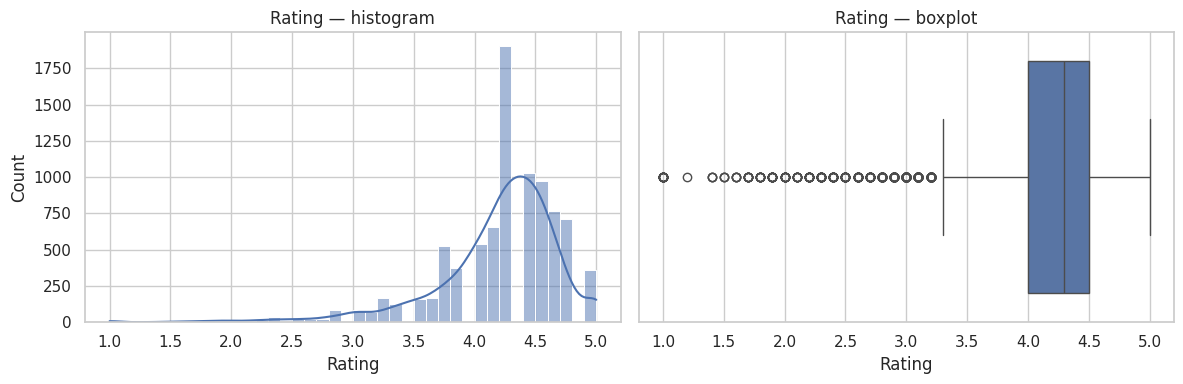

count    8892.000000
mean        4.187877
std         0.522377
min         1.000000
25%         4.000000
50%         4.300000
75%         4.500000
max         5.000000
Name: Rating, dtype: float64
IQR outlier bounds (1.5x rule): [3.25, 5.25]
outliers: 495 rows (5.57% of non-missing data)
  below lower bound: 495, above upper bound: 0


In [11]:
# Rating (the regression target) still has NaNs here — the distribution helper's quantile/describe calls skip NaN automatically, so this is safe.
plot_numeric_distribution(df, "Rating")

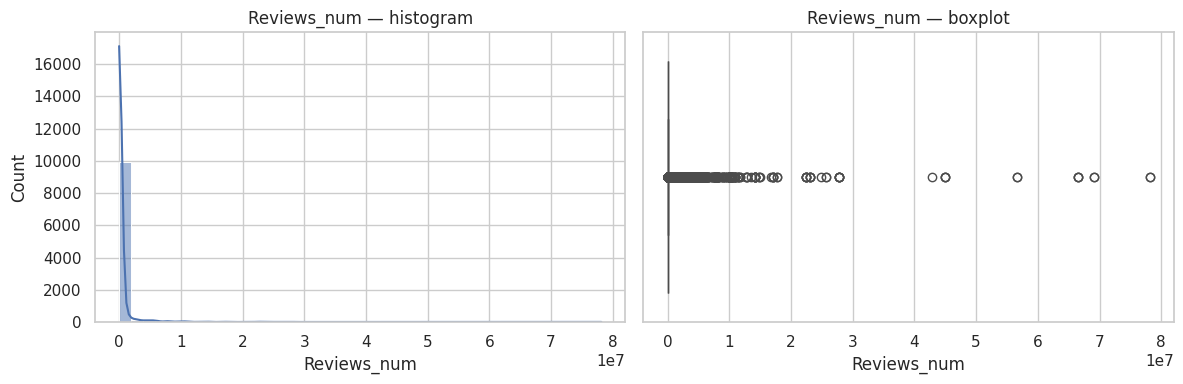

count    1.035700e+04
mean     4.059046e+05
std      2.696778e+06
min      0.000000e+00
25%      3.200000e+01
50%      1.680000e+03
75%      4.641600e+04
max      7.815831e+07
Name: Reviews_num, dtype: float64
IQR outlier bounds (1.5x rule): [-69544.00, 115992.00]
outliers: 1870 rows (18.06% of non-missing data)
  below lower bound: 0, above upper bound: 1870


In [12]:
plot_numeric_distribution(df, "Reviews_num")

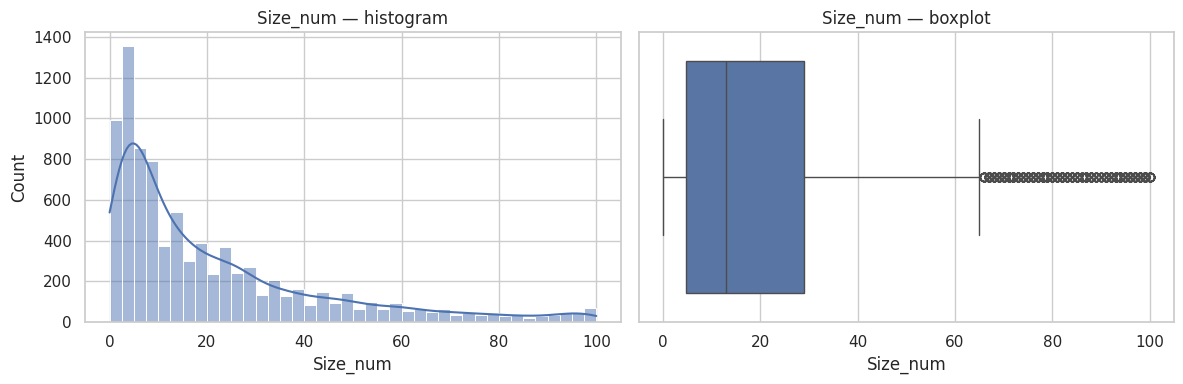

count    8831.000000
mean       21.287413
std        22.540591
min         0.008301
25%         4.700000
50%        13.000000
75%        29.000000
max       100.000000
Name: Size_num, dtype: float64
IQR outlier bounds (1.5x rule): [-31.75, 65.45]
outliers: 582 rows (6.59% of non-missing data)
  below lower bound: 0, above upper bound: 582


In [13]:
plot_numeric_distribution(df, "Size_num")

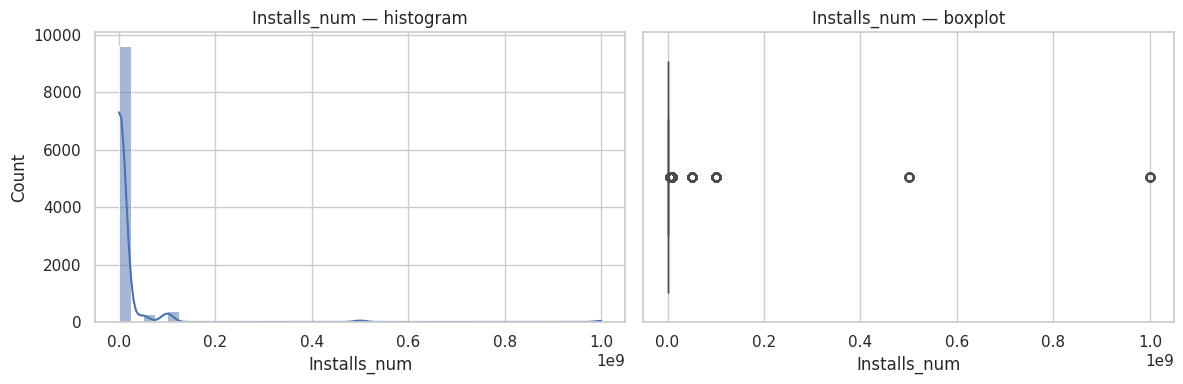

count    1.035700e+04
mean     1.415776e+07
std      8.023955e+07
min      0.000000e+00
25%      1.000000e+03
50%      1.000000e+05
75%      1.000000e+06
max      1.000000e+09
Name: Installs_num, dtype: float64
IQR outlier bounds (1.5x rule): [-1497500.00, 2498500.00]
outliers: 2566 rows (24.78% of non-missing data)
  below lower bound: 0, above upper bound: 2566


In [14]:
plot_numeric_distribution(df, "Installs_num")

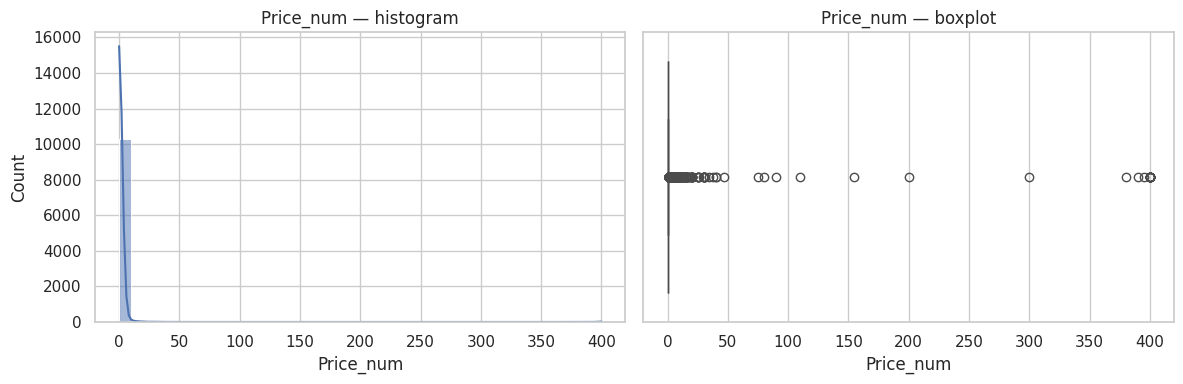

count    10357.000000
mean         1.030800
std         16.278625
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        400.000000
Name: Price_num, dtype: float64
IQR outlier bounds (1.5x rule): [0.00, 0.00]
outliers: 765 rows (7.39% of non-missing data)
  below lower bound: 0, above upper bound: 765


In [15]:
plot_numeric_distribution(df, "Price_num")

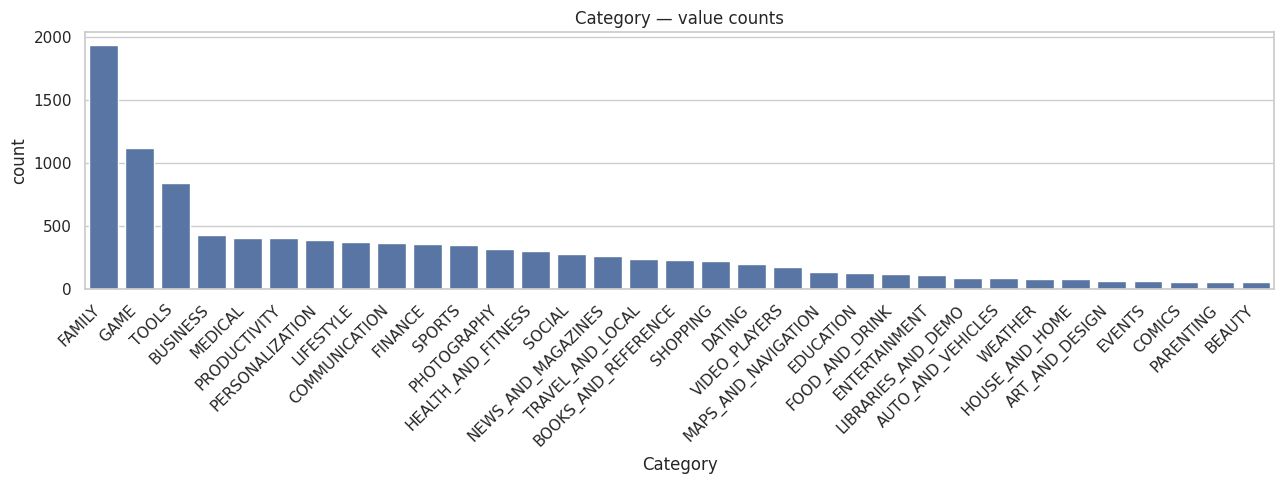

Category
FAMILY                 0.188
GAME                   0.108
TOOLS                  0.081
BUSINESS               0.041
MEDICAL                0.039
PRODUCTIVITY           0.039
PERSONALIZATION        0.037
LIFESTYLE              0.036
COMMUNICATION          0.035
FINANCE                0.035
SPORTS                 0.034
PHOTOGRAPHY            0.031
HEALTH_AND_FITNESS     0.030
SOCIAL                 0.027
NEWS_AND_MAGAZINES     0.025
TRAVEL_AND_LOCAL       0.023
BOOKS_AND_REFERENCE    0.022
SHOPPING               0.022
DATING                 0.019
VIDEO_PLAYERS          0.017
MAPS_AND_NAVIGATION    0.013
EDUCATION              0.013
FOOD_AND_DRINK         0.012
ENTERTAINMENT          0.011
LIBRARIES_AND_DEMO     0.008
AUTO_AND_VEHICLES      0.008
WEATHER                0.008
HOUSE_AND_HOME         0.008
ART_AND_DESIGN         0.006
EVENTS                 0.006
COMICS                 0.006
PARENTING              0.006
BEAUTY                 0.005
Name: proportion, dtype: float64


In [16]:
plot_categorical_distribution(df, "Category", figsize=(13, 5))

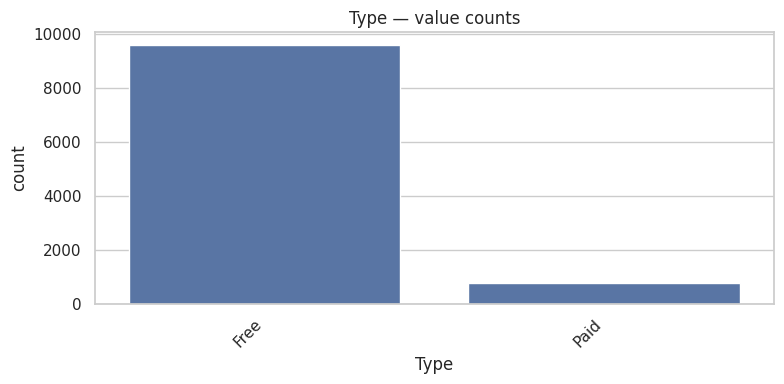

Type
Free    0.926
Paid    0.074
Name: proportion, dtype: float64


In [17]:
plot_categorical_distribution(df, "Type")

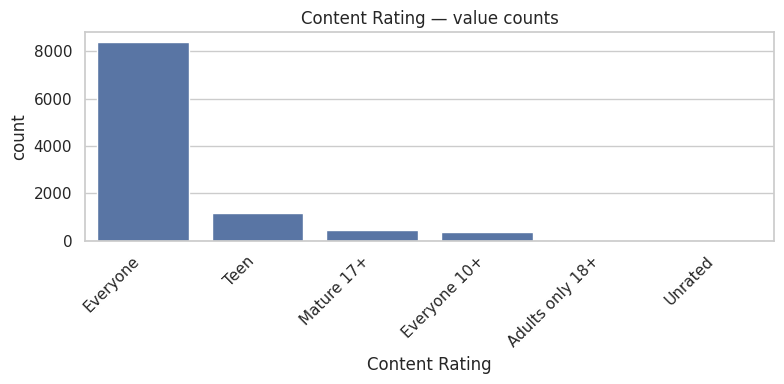

Content Rating
Everyone           0.809
Teen               0.111
Mature 17+         0.043
Everyone 10+       0.036
Adults only 18+    0.000
Unrated            0.000
Name: proportion, dtype: float64


In [18]:
plot_categorical_distribution(df, "Content Rating")

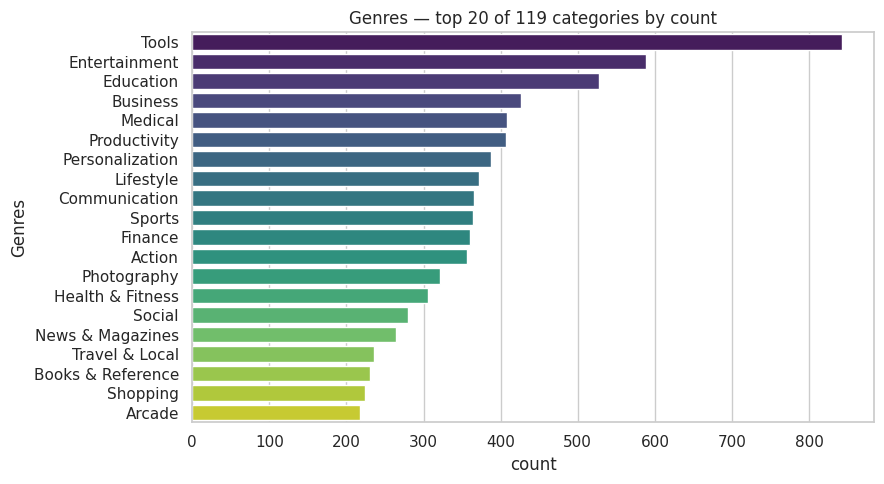

top 20 categories cover 72.3% of rows


In [19]:
plot_top_categorical_distribution(df, "Genres")

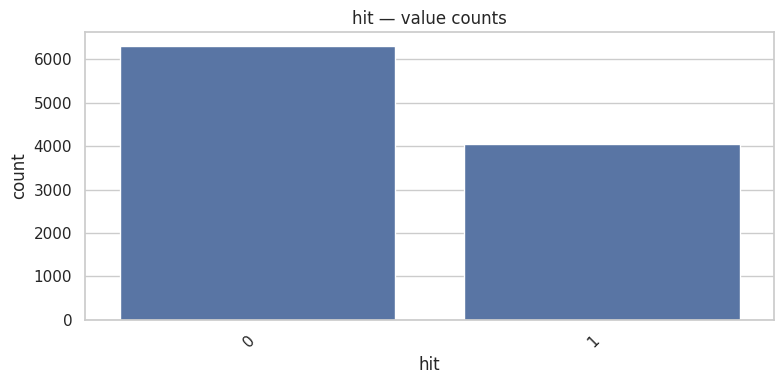

hit
0    0.609
1    0.391
Name: proportion, dtype: float64
class balance — 'hit' apps (installs >= 1,000,000): 39.1%


In [20]:
plot_categorical_distribution(df, "hit")
print(f"class balance — 'hit' apps (installs >= 1,000,000): {df['hit'].mean():.1%}")

## Relevance vs. Classification Target (hit) — Correlation First

In [21]:
numeric_cols = ["Reviews_num", "Size_num", "Price_num", "Rating"]
categorical_cols = ["Category", "Type", "Content Rating", "Genres"]
# Installs_num is excluded — it's the literal basis of the hit target (hit = Installs_num >= 1e6),
# so any correlation with it would be circular, not predictive signal.

def cramers_v(a, b):
    mask = a.notna() & b.notna()
    table = pd.crosstab(a[mask], b[mask])
    chi2 = chi2_contingency(table)[0]
    n = table.to_numpy().sum()
    r, k = table.shape
    return np.sqrt((chi2 / n) / (min(r, k) - 1))

def point_biserial(a, target):
    mask = a.notna()
    corr, _ = pointbiserialr(target[mask], a[mask])
    return abs(corr)

relevance = {}
for col in numeric_cols:
    relevance[col] = point_biserial(df[col], df["hit"])
for col in categorical_cols:
    relevance[col] = cramers_v(df[col], df["hit"])

relevance = pd.Series(relevance).sort_values(ascending=False)
relevance_df = relevance.rename("relevance_score").to_frame()
relevance_df["type"] = ["numeric" if c in numeric_cols else "categorical" for c in relevance_df.index]
relevance_df

,relevance_score,type
Genres,0.360451,categorical
Category,0.330989,categorical
Size_num,0.317793,numeric
Type,0.207986,categorical
Reviews_num,0.186962,numeric
Rating,0.156416,numeric
Content Rating,0.136820,categorical
Price_num,0.049945,numeric


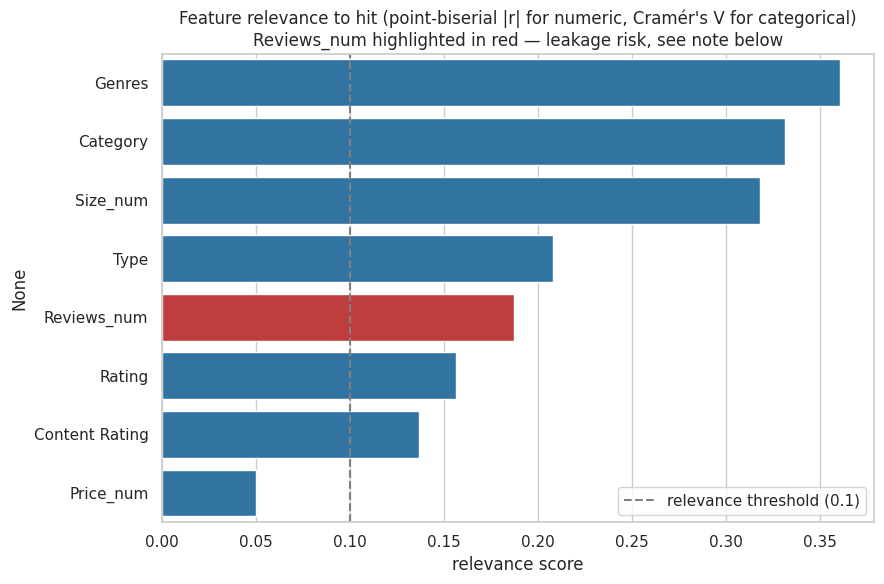

features clearing relevance threshold (0.1): ['Genres', 'Category', 'Size_num', 'Type', 'Reviews_num', 'Rating', 'Content Rating']


In [22]:
plt.figure(figsize=(9, 6))
colors = ["#d62728" if c == "Reviews_num" else "#1f77b4" for c in relevance.index]
sns.barplot(x=relevance.values, y=relevance.index, hue=relevance.index, palette=colors, legend=False)
plt.axvline(0.1, color="gray", linestyle="--", label="relevance threshold (0.1)")
plt.title("Feature relevance to hit (point-biserial |r| for numeric, Cramér's V for categorical)\nReviews_num highlighted in red — leakage risk, see note below")
plt.xlabel("relevance score")
plt.legend()
plt.tight_layout()
plt.show()

RELEVANCE_THRESHOLD = 0.1
top_features = relevance[relevance >= RELEVANCE_THRESHOLD].index.tolist()
print(f"features clearing relevance threshold ({RELEVANCE_THRESHOLD}): {top_features}")

In [23]:
print("leakage note: Reviews_num (review count) scales with Installs_num by construction — a "
      "review can only be written after a download, so more installs mechanically means more "
      "potential reviewers. Since hit is defined directly from Installs_num, Reviews_num inherits "
      "that relationship without being a genuine causal driver of hit.")
df.groupby("hit")["Reviews_num"].agg(["median", "mean"])

leakage note: Reviews_num (review count) scales with Installs_num by construction — a review can only be written after a download, so more installs mechanically means more potential reviewers. Since hit is defined directly from Installs_num, Reviews_num inherits that relationship without being a genuine causal driver of hit.


,median,mean
hit,,
0,76.0,1.565063e+03
1,91378.0,1.034556e+06


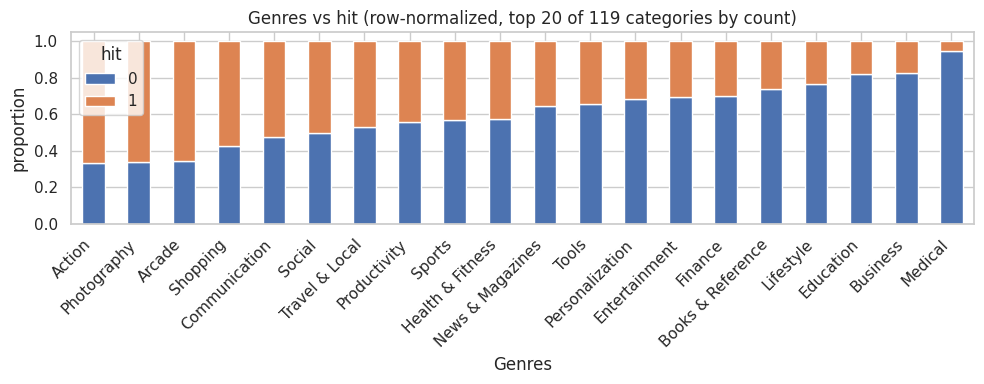

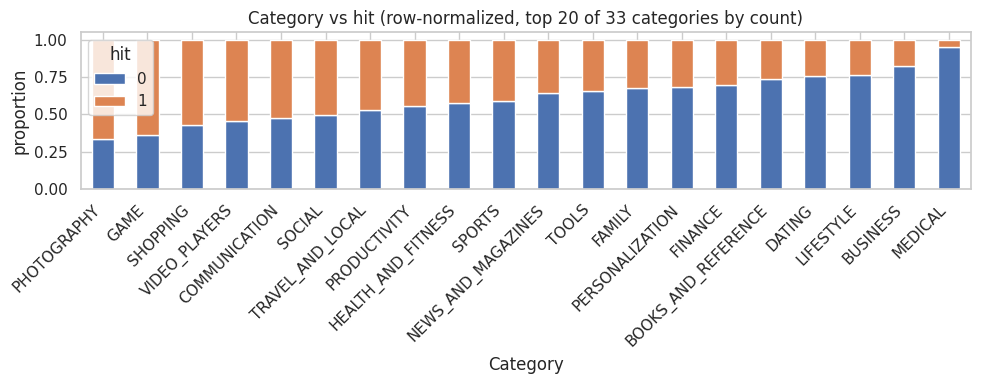

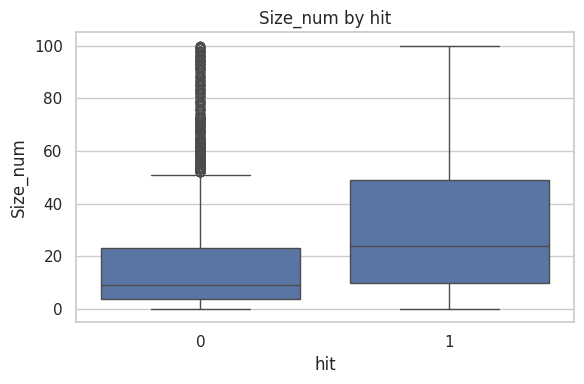

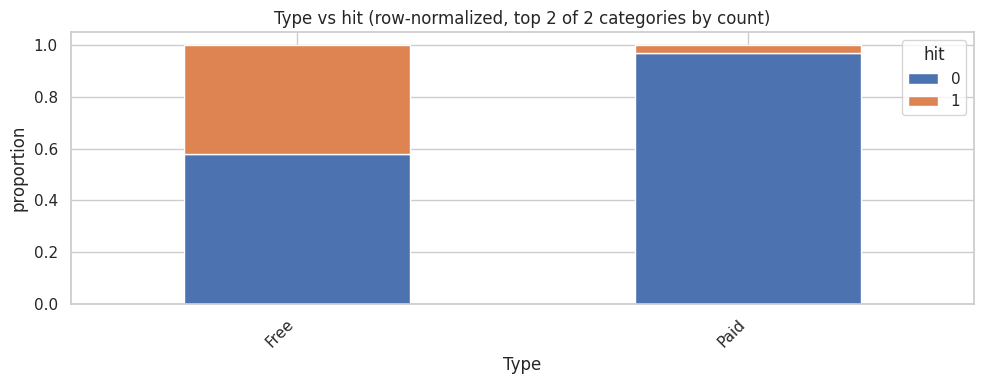

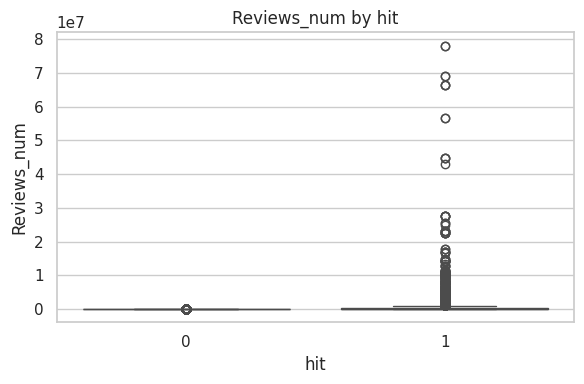

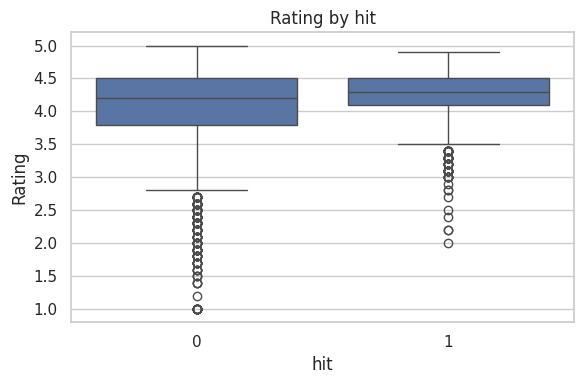

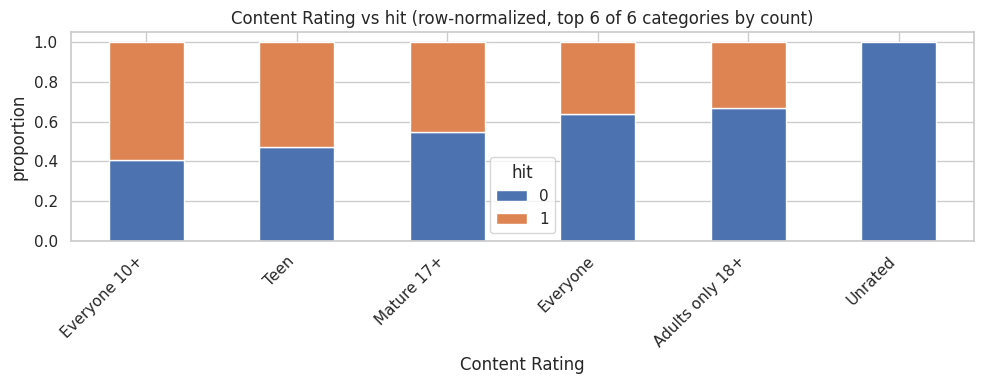

In [24]:
def plot_numeric_vs_target(df, col, target="hit"):
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[target], y=df[col])
    plt.title(f"{col} by {target}")
    plt.tight_layout()
    plt.show()

def plot_categorical_vs_target(df, col, target="hit", top_n=20):
    ct = pd.crosstab(df[col], df[target], normalize="index")
    keep = df[col].value_counts().head(top_n).index
    ct = ct.loc[ct.index.intersection(keep)]
    order = ct.sort_values(by=ct.columns[-1], ascending=False).index
    ct.loc[order].plot(kind="bar", stacked=True, figsize=(10, 4))
    plt.title(f"{col} vs {target} (row-normalized, top {len(order)} of {df[col].nunique()} categories by count)")
    plt.ylabel("proportion")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

for col in top_features:
    if col in numeric_cols:
        plot_numeric_vs_target(df, col)
    else:
        plot_categorical_vs_target(df, col)

## Multicollinearity (numeric feature-to-feature)

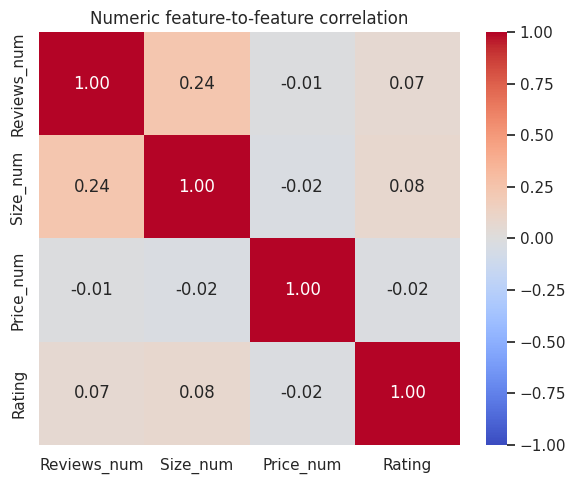

In [25]:
corr_matrix = df[numeric_cols].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Numeric feature-to-feature correlation")
plt.tight_layout()
plt.show()

## Deep Dive — Categorical-Categorical Redundancy (hit)

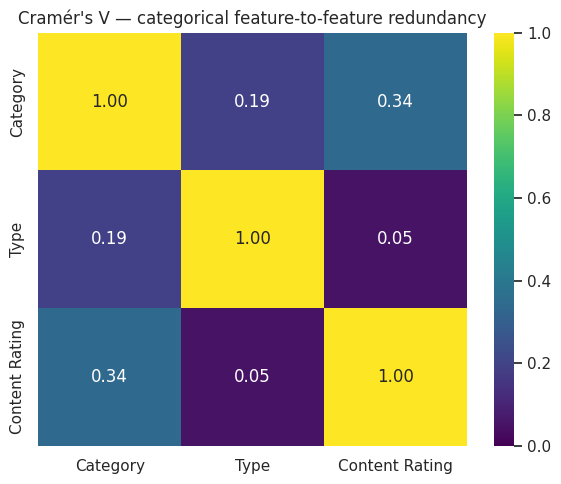

In [26]:
cat_redundancy_cols = ["Category", "Type", "Content Rating"]

cramers_matrix = pd.DataFrame(index=cat_redundancy_cols, columns=cat_redundancy_cols, dtype=float)
for c1 in cat_redundancy_cols:
    for c2 in cat_redundancy_cols:
        cramers_matrix.loc[c1, c2] = 1.0 if c1 == c2 else cramers_v(df[c1], df[c2])

plt.figure(figsize=(6, 5))
sns.heatmap(cramers_matrix.astype(float), annot=True, fmt=".2f", cmap="viridis", vmin=0, vmax=1)
plt.title("Cramér's V — categorical feature-to-feature redundancy")
plt.tight_layout()
plt.show()

In [27]:
# Genres (119 categories) excluded from the matrix above — unreadable as a heatmap and expensive
# to compute pairwise at that cardinality. Checked individually against the others instead.
genres_redundancy = pd.Series({
    "Category": cramers_v(df["Genres"], df["Category"]),
    "Content Rating": cramers_v(df["Genres"], df["Content Rating"]),
    "Type": cramers_v(df["Genres"], df["Type"]),
}).sort_values(ascending=False)
genres_redundancy

Category          0.969154
Content Rating    0.388409
Type              0.268016
dtype: float64

## Model-Based Feature Importance (RF)

In [28]:
def build_feature_matrix(df, num_cols, cat_cols):
    X_num = df[num_cols].copy()
    for c in num_cols:
        X_num[c] = X_num[c].fillna(X_num[c].median())
    frames = [X_num]
    col_to_parent = {c: c for c in num_cols}
    for col in cat_cols:
        dummies = pd.get_dummies(df[col].fillna("__missing__"), prefix=col)
        frames.append(dummies)
        col_to_parent.update({d: col for d in dummies.columns})
    return pd.concat(frames, axis=1), col_to_parent

# Median-fill for NaNs (Size_num, Rating) is a modeling-only convenience for RF/MI, which need a
# complete matrix — not applied anywhere else in the notebook.
X_clf, col_to_parent_clf = build_feature_matrix(df, numeric_cols, categorical_cols)
rf_clf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf_clf.fit(X_clf, df["hit"])

importances_clf = pd.Series(rf_clf.feature_importances_, index=X_clf.columns)
importances_clf_agg = importances_clf.groupby(col_to_parent_clf).sum().sort_values(ascending=False)
importances_clf_agg

Reviews_num       0.690124
Size_num          0.106380
Genres            0.056638
Rating            0.052480
Category          0.044947
Type              0.024364
Content Rating    0.012624
Price_num         0.012444
dtype: float64

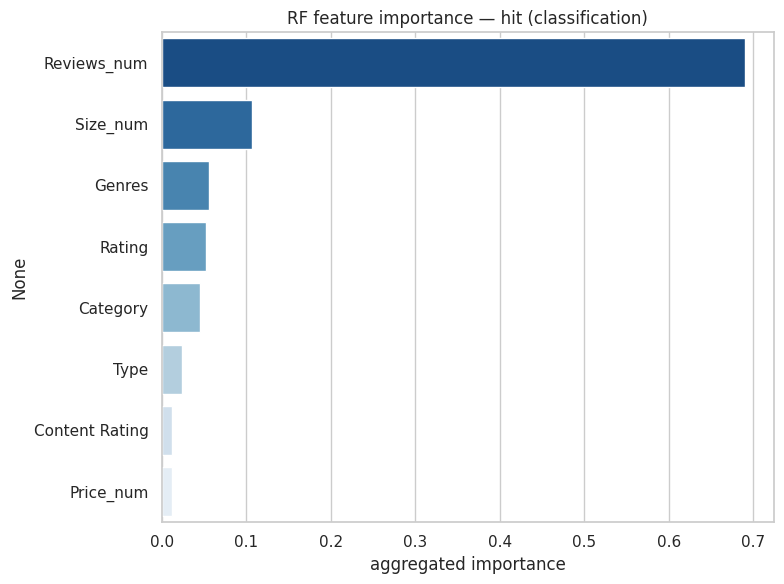

In [29]:
plt.figure(figsize=(8, 6))
sns.barplot(x=importances_clf_agg.values, y=importances_clf_agg.index, hue=importances_clf_agg.index,
            palette="Blues_r", legend=False)
plt.title("RF feature importance — hit (classification)")
plt.xlabel("aggregated importance")
plt.tight_layout()
plt.show()

## Relevance Cross-Check — Mutual Information

In [30]:
from sklearn.feature_selection import mutual_info_classif

mi_numeric = pd.Series(
    mutual_info_classif(X_clf[numeric_cols], df["hit"], discrete_features=False, random_state=42),
    index=numeric_cols,
)

cat_codes = df[categorical_cols].fillna("__missing__").apply(lambda s: pd.factorize(s)[0])
mi_categorical = pd.Series(
    mutual_info_classif(cat_codes, df["hit"], discrete_features=True, random_state=42),
    index=categorical_cols,
)

mi_relevance = pd.concat([mi_numeric, mi_categorical]).sort_values(ascending=False)
mi_relevance_df = mi_relevance.rename("mutual_info").to_frame()
mi_relevance_df["type"] = ["numeric" if c in numeric_cols else "categorical" for c in mi_relevance_df.index]
mi_relevance_df

,mutual_info,type
Reviews_num,0.538760,numeric
Size_num,0.093602,numeric
Rating,0.073666,numeric
Genres,0.070421,categorical
Category,0.058362,categorical
Type,0.029046,categorical
Price_num,0.025879,numeric
Content Rating,0.009191,categorical


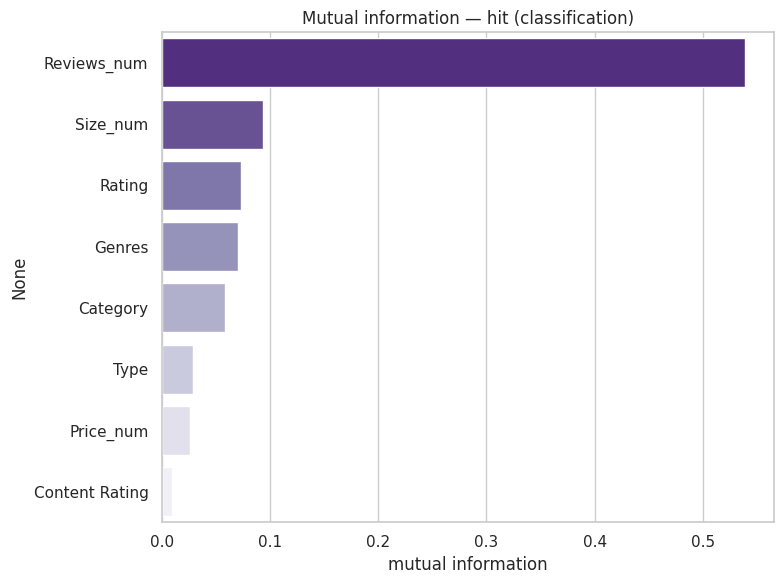

In [31]:
plt.figure(figsize=(8, 6))
sns.barplot(x=mi_relevance.values, y=mi_relevance.index, hue=mi_relevance.index,
            palette="Purples_r", legend=False)
plt.title("Mutual information — hit (classification)")
plt.xlabel("mutual information")
plt.tight_layout()
plt.show()